# EDA Dataset JSONL

Notebook ini melakukan eksplorasi untuk tiga file:

- `apm1_iaaa.jsonl`
- `apm1_iaaa_textcat.jsonl`
- `db_apm1_genap2526_v2.jsonl`

Hasil visualisasi dan tabel ringkasan akan disimpan ke folder output.

In [22]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../dataset/jsonL')
OUTDIR = Path('../notebook/eda_outputs')
OUTDIR.mkdir(parents=True, exist_ok=True)

FILE_IAAA = DATA_DIR / 'apm1_iaaa.jsonl'
FILE_TEXTCAT = DATA_DIR / 'apm1_iaaa_textcat.jsonl'
FILE_ANNOTATED = DATA_DIR / 'db_apm1_genap2526_v2.jsonl'

print('DATA_DIR:', DATA_DIR.resolve())
print('OUTDIR:', OUTDIR.resolve())

DATA_DIR: C:\Users\Nicholas\OneDrive - Universitas Atma Jaya Yogyakarta (1)\1_S2\Penerapan Machine Learning\UTS\Project\dataset\jsonL
OUTDIR: C:\Users\Nicholas\OneDrive - Universitas Atma Jaya Yogyakarta (1)\1_S2\Penerapan Machine Learning\UTS\Project\notebook\eda_outputs


In [23]:
def read_json_or_jsonl(path: Path):
    """Membaca file JSON tunggal atau JSONL."""
    text = path.read_text(encoding='utf-8').strip()
    if not text:
        raise ValueError(f'File kosong: {path}')

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        records = []
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
        return records


def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUTDIR / name, dpi=160, bbox_inches='tight')


def safe_len(value):
    try:
        return len(value)
    except Exception:
        return np.nan

## 1) EDA `apm1_iaaa.jsonl`

File ini berisi ringkasan metrik anotasi dan confusion matrix.

In [24]:
iaaa = read_json_or_jsonl(FILE_IAAA)
type(iaaa), iaaa.keys()

(dict,
 dict_keys(['n_examples', 'n_categories', 'n_coincident_examples', 'n_single_annotation', 'n_annotators', 'avg_raters_per_example', 'pairwise_f1', 'pairwise_recall', 'pairwise_precision', 'confusion_matrix', 'normalized_confusion_matrix', 'metrics_per_label']))

In [25]:
iaaa_summary = pd.Series({
    'n_examples': iaaa.get('n_examples'),
    'n_categories': iaaa.get('n_categories'),
    'n_coincident_examples': iaaa.get('n_coincident_examples'),
    'n_single_annotation': iaaa.get('n_single_annotation'),
    'n_annotators': iaaa.get('n_annotators'),
    'avg_raters_per_example': iaaa.get('avg_raters_per_example'),
    'pairwise_f1': iaaa.get('pairwise_f1'),
    'pairwise_recall': iaaa.get('pairwise_recall'),
    'pairwise_precision': iaaa.get('pairwise_precision'),
}, name='summary')
display(iaaa_summary.to_frame())

,summary
n_examples,1044.00
n_categories,5.00
n_coincident_examples,522.00
n_single_annotation,0.00
n_annotators,2.00
avg_raters_per_example,2.00
pairwise_f1,0.38
pairwise_recall,0.35
pairwise_precision,0.49


In [26]:
df_iaaa_metrics = pd.DataFrame(iaaa['metrics_per_label']).T.reset_index().rename(columns={'index': 'label'})
df_iaaa_metrics = df_iaaa_metrics[['label', 'p', 'r', 'f1', 'support']].sort_values('support', ascending=False)
display(df_iaaa_metrics)

df_iaaa_metrics.to_csv(OUTDIR / 'apm1_iaaa_metrics_per_label.csv', index=False)

,label,p,r,f1,support
1,PER-PM,0.624230,0.445748,0.520103,682.0
2,ORGANIZATION,0.635714,0.133634,0.220844,666.0
4,MEDICAL,0.624319,0.576214,0.599303,597.0
3,LOCATION,0.474619,0.367387,0.414175,509.0
0,PER-PTG,0.100000,0.235294,0.140351,85.0


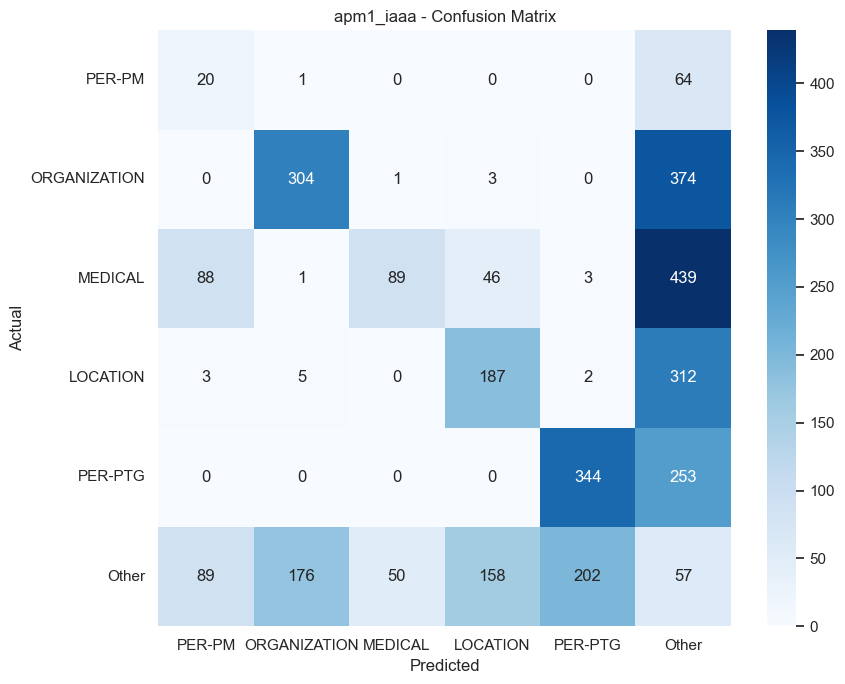

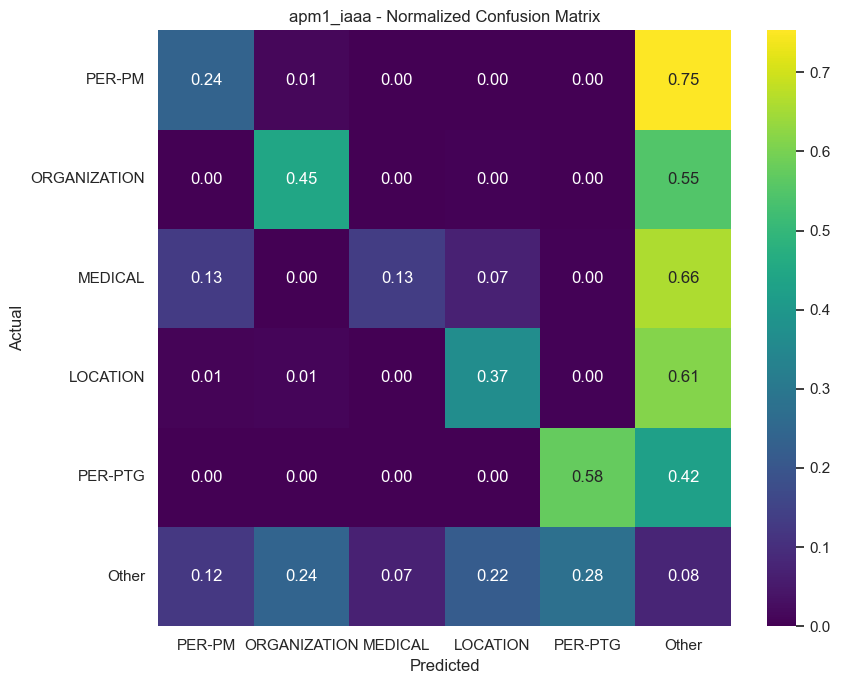

In [27]:
cm = np.array(iaaa['confusion_matrix'])
ncm = np.array(iaaa['normalized_confusion_matrix'])
labels = df_iaaa_metrics['label'].tolist()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=labels + ['Other'], yticklabels=labels + ['Other'], ax=ax)
ax.set_title('apm1_iaaa - Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
save_fig('apm1_iaaa_confusion_matrix_counts.png')
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ncm, annot=True, fmt='.2f', cmap='viridis', xticklabels=labels + ['Other'], yticklabels=labels + ['Other'], ax=ax)
ax.set_title('apm1_iaaa - Normalized Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
save_fig('apm1_iaaa_confusion_matrix_normalized.png')
plt.show()

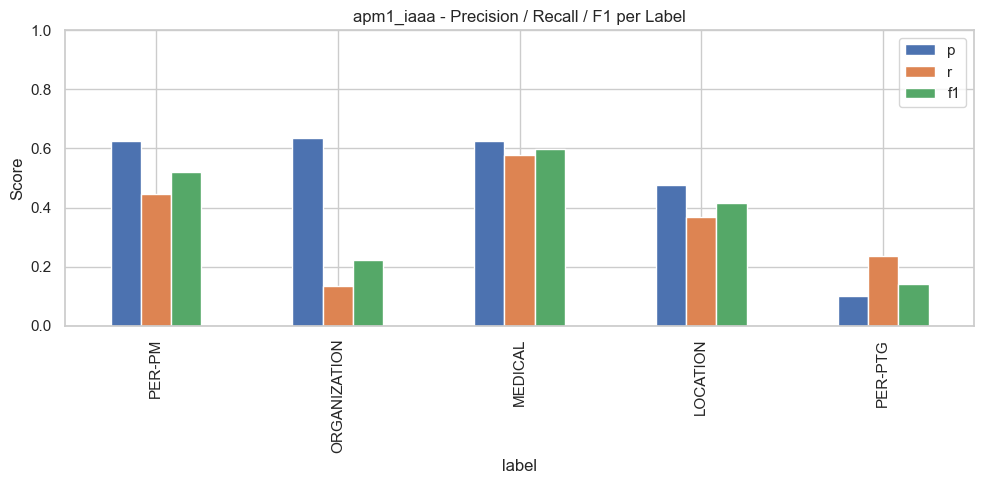

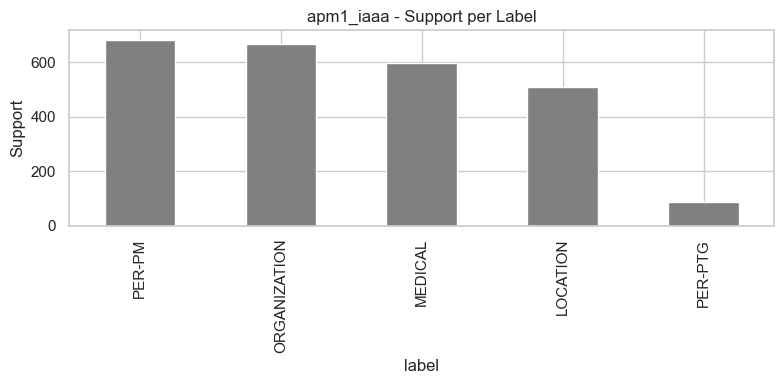

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df_iaaa_metrics.set_index('label')[['p', 'r', 'f1']]
plot_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('apm1_iaaa - Precision / Recall / F1 per Label')
ax.set_ylabel('Score')
save_fig('apm1_iaaa_prf_per_label.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df_iaaa_metrics.set_index('label')['support'].plot(kind='bar', color='gray', ax=ax)
ax.set_title('apm1_iaaa - Support per Label')
ax.set_ylabel('Support')
save_fig('apm1_iaaa_support_per_label.png')
plt.show()

## 2) EDA `apm1_iaaa_textcat.jsonl`

File ini berisi metrik agreement untuk beberapa kategori seperti `MANFAAT_*` dan `KUALITAS_*`.

In [29]:
iaaa_textcat = read_json_or_jsonl(FILE_TEXTCAT)
type(iaaa_textcat), list(iaaa_textcat.keys())[:3]

(dict, ['MANFAAT_POSITIVE', 'MANFAAT_NEGATIVE', 'MANFAAT_NEUTRAL'])

In [30]:
textcat_rows = []
for label_name, metrics in iaaa_textcat.items():
    textcat_rows.append({
        'label_name': label_name,
        'n_examples': metrics.get('n_examples'),
        'n_categories': metrics.get('n_categories'),
        'n_coincident_examples': metrics.get('n_coincident_examples'),
        'n_single_annotation': metrics.get('n_single_annotation'),
        'n_annotators': metrics.get('n_annotators'),
        'avg_raters_per_example': metrics.get('avg_raters_per_example'),
        'percent_agreement': metrics.get('percent_agreement'),
        'kripp_alpha': metrics.get('kripp_alpha'),
        'gwet_ac2': metrics.get('gwet_ac2'),
    })

df_textcat = pd.DataFrame(textcat_rows).sort_values('label_name')
display(df_textcat)

df_textcat.to_csv(OUTDIR / 'apm1_iaaa_textcat_agreement_metrics.csv', index=False)

,label_name,n_examples,n_categories,n_coincident_examples,n_single_annotation,n_annotators,avg_raters_per_example,percent_agreement,kripp_alpha,gwet_ac2
4,KUALITAS_NEGATIVE,1011,6,491,31,2,1.936782,0.995927,3.648585e-12,0.995911
5,KUALITAS_NEUTRAL,1011,6,491,31,2,1.936782,0.971487,1.207599e-01,0.970599
3,KUALITAS_POSITIVE,1011,6,491,31,2,1.936782,0.945010,4.509304e-02,0.941871
1,MANFAAT_NEGATIVE,1011,6,491,31,2,1.936782,0.997963,0.000000e+00,0.997952
2,MANFAAT_NEUTRAL,1011,6,491,31,2,1.936782,0.906314,7.015766e-02,0.896124
0,MANFAAT_POSITIVE,1011,6,491,31,2,1.936782,0.904277,3.282919e-01,0.889548


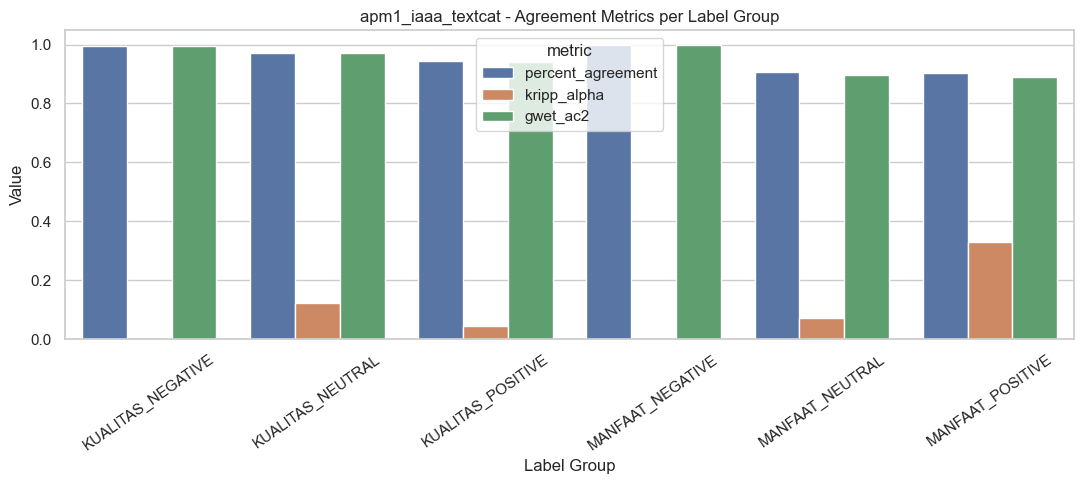

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
melted = df_textcat.melt(id_vars='label_name', value_vars=['percent_agreement', 'kripp_alpha', 'gwet_ac2'],
                         var_name='metric', value_name='value')
sns.barplot(data=melted, x='label_name', y='value', hue='metric', ax=ax)
ax.set_title('apm1_iaaa_textcat - Agreement Metrics per Label Group')
ax.set_xlabel('Label Group')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=35)
save_fig('apm1_iaaa_textcat_agreement_metrics.png')
plt.show()

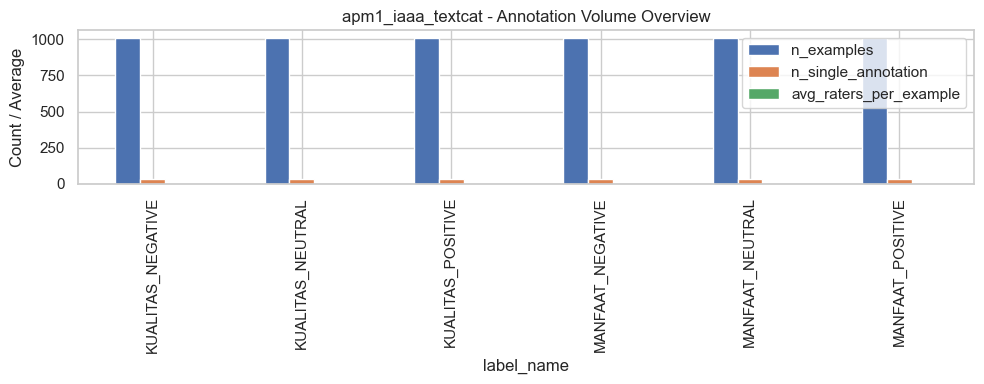

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
df_textcat.set_index('label_name')[['n_examples', 'n_single_annotation', 'avg_raters_per_example']].plot(kind='bar', ax=ax)
ax.set_title('apm1_iaaa_textcat - Annotation Volume Overview')
ax.set_ylabel('Count / Average')
save_fig('apm1_iaaa_textcat_volume_overview.png')
plt.show()

## 3) EDA `db_apm1_genap2526_v2.jsonl`

File ini berisi data anotasi berbasis teks dengan token dan span label. EDA di bawah menghitung panjang teks, jumlah token, jumlah span, dan distribusi label span.

In [33]:
annotated_records = read_json_or_jsonl(FILE_ANNOTATED)
df_annot = pd.DataFrame(annotated_records)

print('Shape:', df_annot.shape)
display(df_annot.head())
display(df_annot.columns.to_series())

Shape: (1044, 14)


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,config,accept,answer,_timestamp,_annotator_id,_session_id,flagged
0,mari kita datangi fasilitas kesehatan yang ada untuk cek kesehatan gratis.,"[{'text': 'mari', 'start': 0, 'end': 4, 'id': 0, 'ws': True}, {'text': 'kita', 'start': 5, 'end': 9, 'id': 1, 'ws': ...",[],-1579256674,-894085032,"[{'id': 'MANFAAT_POSITIVE', 'text': 'MANFAAT_POSITIVE'}, {'id': 'MANFAAT_NEGATIVE', 'text': 'MANFAAT_NEGATIVE'}, {'i...",blocks,{'choice_style': 'multiple'},"[MANFAAT_NEUTRAL, KUALITAS_NEUTRAL]",accept,1776348819,apm1_genap2526_v2-255313636,apm1_genap2526_v2-255313636,NaN
1,"jangan lewatkan kesempatan ini. bapa mama to o te o dong mari su datang. jang tunggu sakit do baru periksa, lebih ba...","[{'text': 'jangan', 'start': 0, 'end': 6, 'id': 0, 'ws': True}, {'text': 'lewatkan', 'start': 7, 'end': 15, 'id': 1,...","[{'start': 195, 'end': 208, 'token_start': 40, 'token_end': 41, 'label': 'PER-PTG'}, {'start': 213, 'end': 220, 'tok...",-848894538,1272581982,"[{'id': 'MANFAAT_POSITIVE', 'text': 'MANFAAT_POSITIVE'}, {'id': 'MANFAAT_NEGATIVE', 'text': 'MANFAAT_NEGATIVE'}, {'i...",blocks,{'choice_style': 'multiple'},"[MANFAAT_NEUTRAL, KUALITAS_NEUTRAL]",accept,1776348872,apm1_genap2526_v2-255313636,apm1_genap2526_v2-255313636,NaN
2,cek kesehatan gratis ckg anak sekolah adalah program puskesmas untuk mendeteksi dini risiko kesehatan siswa- siswi 7...,"[{'text': 'cek', 'start': 0, 'end': 3, 'id': 0, 'ws': True}, {'text': 'kesehatan', 'start': 4, 'end': 13, 'id': 1, '...","[{'start': 25, 'end': 37, 'token_start': 4, 'token_end': 5, 'label': 'PER-PM'}, {'start': 53, 'end': 62, 'token_star...",1471818211,-1204482112,"[{'id': 'MANFAAT_POSITIVE', 'text': 'MANFAAT_POSITIVE'}, {'id': 'MANFAAT_NEGATIVE', 'text': 'MANFAAT_NEGATIVE'}, {'i...",blocks,{'choice_style': 'multiple'},"[MANFAAT_NEUTRAL, KUALITAS_NEUTRAL]",accept,1776348984,apm1_genap2526_v2-255313636,apm1_genap2526_v2-255313636,NaN
3,personil kompi kesehatan yonif tp 834 wm melaksanakan kegiatan ckg cek kesehatan gratis sebagai bentuk kepedulian te...,"[{'text': 'personil', 'start': 0, 'end': 8, 'id': 0, 'ws': True}, {'text': 'kompi', 'start': 9, 'end': 14, 'id': 1, ...","[{'start': 9, 'end': 40, 'token_start': 1, 'token_end': 6, 'label': 'PER-PTG'}, {'start': 133, 'end': 143, 'token_st...",494824588,-1765938836,"[{'id': 'MANFAAT_POSITIVE', 'text': 'MANFAAT_POSITIVE'}, {'id': 'MANFAAT_NEGATIVE', 'text': 'MANFAAT_NEGATIVE'}, {'i...",blocks,{'choice_style': 'multiple'},"[MANFAAT_NEUTRAL, KUALITAS_NEUTRAL]",accept,1776349300,apm1_genap2526_v2-255313636,apm1_genap2526_v2-255313636,NaN
4,"assalamu alaikum. warga segarau dan sungai pugok hari itok dangan isok, tgl 8 dan 9 april kite ad cek kesehatan grat...","[{'text': 'assalamu', 'start': 0, 'end': 8, 'id': 0, 'ws': True}, {'text': 'alaikum', 'start': 9, 'end': 16, 'id': 1...","[{'start': 18, 'end': 23, 'token_start': 3, 'token_end': 3, 'label': 'PER-PM'}, {'start': 24, 'end': 31, 'token_star...",1137810068,98179867,"[{'id': 'MANFAAT_POSITIVE', 'text': 'MANFAAT_POSITIVE'}, {'id': 'MANFAAT_NEGATIVE', 'text': 'MANFAAT_NEGATIVE'}, {'i...",blocks,{'choice_style': 'multiple'},"[MANFAAT_NEUTRAL, KUALITAS_NEUTRAL]",accept,1776349547,apm1_genap2526_v2-255313636,apm1_genap2526_v2-255313636,NaN


text                      text
tokens                  tokens
spans                    spans
_input_hash        _input_hash
_task_hash          _task_hash
options                options
_view_id              _view_id
config                  config
accept                  accept
answer                  answer
_timestamp          _timestamp
_annotator_id    _annotator_id
_session_id        _session_id
flagged                flagged
dtype: str

In [34]:
## ambillah anotator unik 
annotators = df_annot['_annotator_id'].unique()

print (f'Jumlah anotator unik: {len(annotators)}')
print('Daftar anotator unik:', annotators)

Jumlah anotator unik: 2
Daftar anotator unik: <StringArray>
['apm1_genap2526_v2-255313636', 'apm1_genap2526_v2-255313481']
Length: 2, dtype: str


Jumlah kontribusi per anotator:
_annotator_id
apm1_genap2526_v2-255313636    522
apm1_genap2526_v2-255313481    522
Name: count, dtype: int64


In [35]:
def extract_record_stats(row):
    text = row.get('text', '')
    tokens = row.get('tokens', [])
    spans = row.get('spans', [])

    span_labels = [s.get('label') for s in spans if isinstance(s, dict)]
    return pd.Series({
        'text_len_char': len(text) if isinstance(text, str) else np.nan,
        'text_len_word': len(str(text).split()) if isinstance(text, str) else np.nan,
        'n_tokens': safe_len(tokens),
        'n_spans': safe_len(spans),
        'span_labels': span_labels,
        'unique_span_labels': len(set(span_labels)),
    })


stats_df = df_annot.apply(extract_record_stats, axis=1)
df_annot_eda = pd.concat([df_annot, stats_df], axis=1)

display(df_annot_eda[['text_len_char', 'text_len_word', 'n_tokens', 'n_spans', 'unique_span_labels']].describe())

,text_len_char,text_len_word,n_tokens,n_spans,unique_span_labels
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,438.321839,60.226054,67.262452,4.294061,1.772031
std,754.637340,105.628914,121.175064,6.434471,1.314330
min,24.000000,5.000000,5.000000,0.000000,0.000000
25%,102.000000,13.000000,14.000000,1.000000,1.000000
50%,215.500000,29.000000,32.000000,2.000000,2.000000
75%,496.000000,67.000000,76.000000,6.000000,3.000000
max,12160.000000,1736.000000,2007.000000,85.000000,5.000000


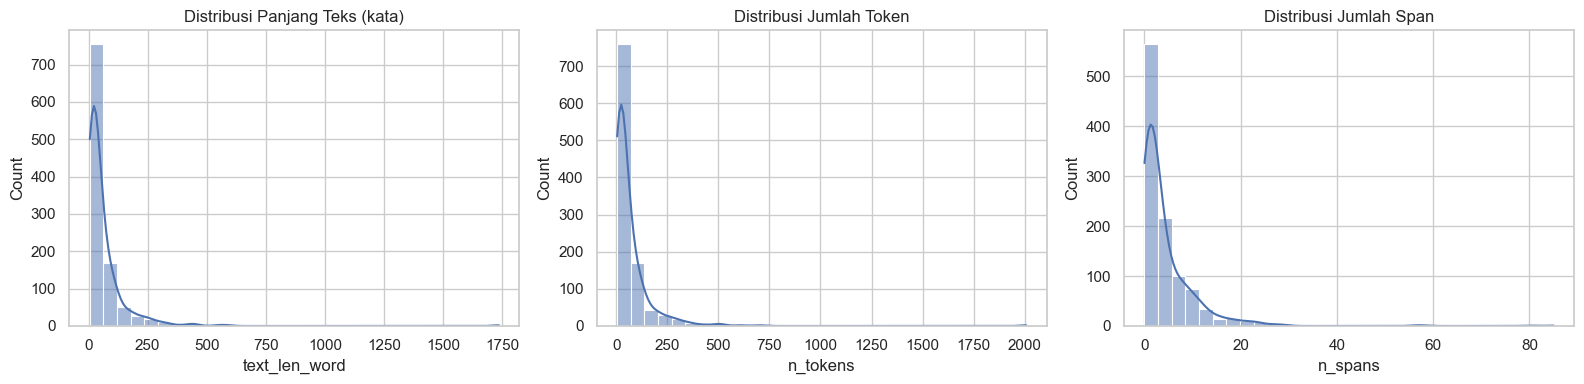

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_annot_eda['text_len_word'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Panjang Teks (kata)')

sns.histplot(df_annot_eda['n_tokens'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Jumlah Token')

sns.histplot(df_annot_eda['n_spans'].dropna(), bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribusi Jumlah Span')

save_fig('db_apm1_genap2526_v2_length_histograms.png')
plt.show()

,count
PER-PM,1211
MEDICAL,1196
LOCATION,955
ORGANIZATION,825
PER-PTG,296


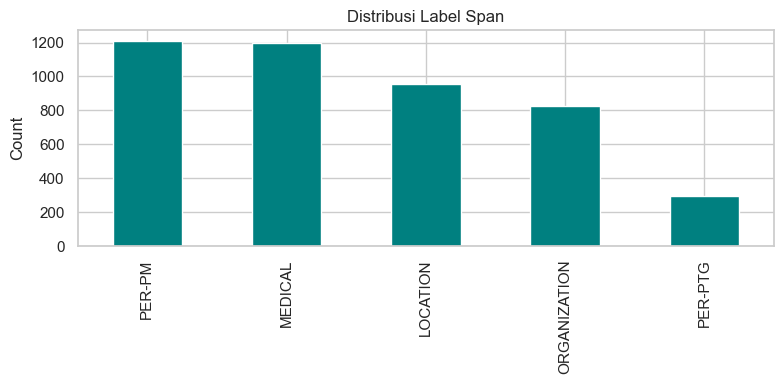

In [37]:
all_span_labels = [label for labels in df_annot_eda['span_labels'] for label in labels if label is not None]
label_counts = pd.Series(all_span_labels).value_counts()
display(label_counts.to_frame('count'))

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Distribusi Label Span')
ax.set_ylabel('Count')
save_fig('db_apm1_genap2526_v2_span_label_distribution.png')
plt.show()

,count
labels_as_text,
LOCATION,127
PER-PM,78
"LOCATION, PER-PM",71
"LOCATION, ORGANIZATION",68
"LOCATION, ORGANIZATION, PER-PM",68
"LOCATION, MEDICAL, ORGANIZATION, PER-PM",57
ORGANIZATION,43
"ORGANIZATION, PER-PM",35
"PER-PM, PER-PTG",28


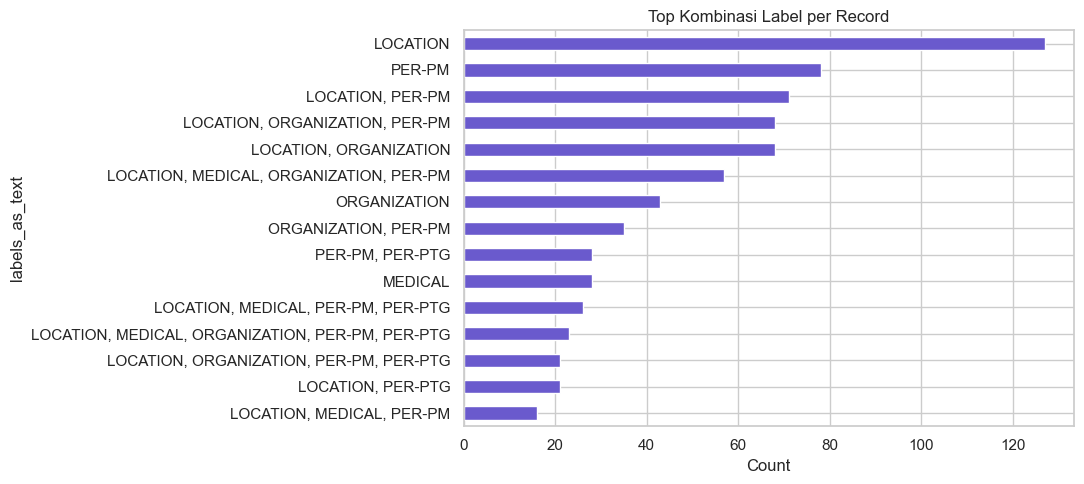

In [38]:
records_with_spans = df_annot_eda[df_annot_eda['n_spans'] > 0].copy()
records_with_spans['labels_as_text'] = records_with_spans['span_labels'].apply(lambda xs: ', '.join(sorted(set(xs))))

top_label_combinations = records_with_spans['labels_as_text'].value_counts().head(15)
display(top_label_combinations.to_frame('count'))

fig, ax = plt.subplots(figsize=(11, 5))
top_label_combinations.sort_values().plot(kind='barh', ax=ax, color='slateblue')
ax.set_title('Top Kombinasi Label per Record')
ax.set_xlabel('Count')
save_fig('db_apm1_genap2526_v2_top_label_combinations.png')
plt.show()

In [39]:
summary_out = {
    'apm1_iaaa': {
        'n_examples': iaaa.get('n_examples'),
        'n_categories': iaaa.get('n_categories'),
        'pairwise_f1': iaaa.get('pairwise_f1'),
        'pairwise_precision': iaaa.get('pairwise_precision'),
        'pairwise_recall': iaaa.get('pairwise_recall')
    },
    'apm1_iaaa_textcat': {
        'labels': list(iaaa_textcat.keys())
    },
    'db_apm1_genap2526_v2': {
        'n_rows': int(len(df_annot)),
        'avg_text_len_word': float(df_annot_eda['text_len_word'].mean()),
        'avg_n_tokens': float(df_annot_eda['n_tokens'].mean()),
        'avg_n_spans': float(df_annot_eda['n_spans'].mean()),
        'span_label_distribution': label_counts.to_dict()
    }
}

(OUTDIR / 'summary.json').write_text(json.dumps(summary_out, indent=2, ensure_ascii=False), encoding='utf-8')
print('Semua hasil EDA tersimpan di:', OUTDIR.resolve())

Semua hasil EDA tersimpan di: C:\Users\Nicholas\OneDrive - Universitas Atma Jaya Yogyakarta (1)\1_S2\Penerapan Machine Learning\UTS\Project\notebook\eda_outputs
